# Exploring GPT2 and BERT embeddings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# higher-res plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import GPT2 and BERT models and tokenizers

In [2]:
from transformers import GPT2Model, GPT2Tokenizer

gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizerG = GPT2Tokenizer.from_pretrained('gpt2')

In [3]:
from transformers import BertModel, BertTokenizer

bert = BertModel.from_pretrained('bert-base-uncased')
tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')

In [4]:
# chek out the GPT2 model
print(gpt2)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [5]:
# check out the BERT model
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

# How long are the tokens?

In [6]:
print(f'BERT has {tokenizerB.vocab_size:,} tokens.')
print(f'GPT2 has {tokenizerG.vocab_size:,} tokens.')

BERT has 30,522 tokens.
GPT2 has 50,257 tokens.


In [7]:
# GPT: get all individual lengths
token_lengths = np.zeros(tokenizerG.vocab_size, dtype=int)

for idx, word in enumerate(tokenizerG.encoder.keys()):
    token_lengths[idx] = len(word)

# unique values and counts for bar plot
unique_lengths_GPT, token_counts_GPT = np.unique(token_lengths, return_counts=True)


# BERT: get all individual lengths
token_lengths = np.zeros(tokenizerB.vocab_size, dtype=int)

for idx, word in enumerate(tokenizerB.get_vocab().keys()):
    token_lengths[idx] = len(word)

# unique values and counts for bar plot
unique_lengths_BERT, token_counts_BERT = np.unique(token_lengths, return_counts=True)

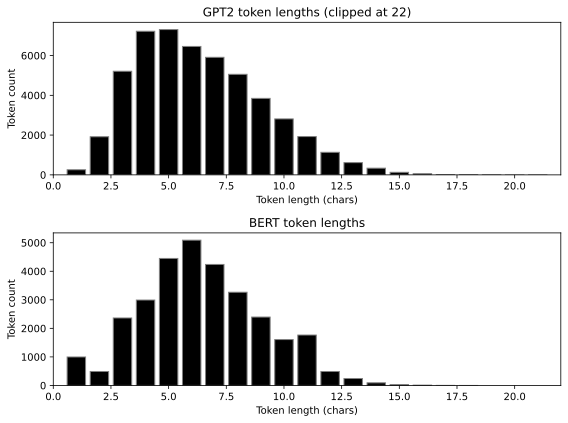

In [9]:
# draw the bar plot
_, axs = plt.subplots(2, 1, figsize=(8,6))
axs[0].bar(unique_lengths_GPT, token_counts_GPT, color='k', edgecolor='gray')
axs[0].set(xlabel="Token length (chars)",
           ylabel="Token count",
           title="GPT2 token lengths (clipped at 22)",
           xlim=[0,22])

axs[1].bar(unique_lengths_BERT, token_counts_BERT, color='k', edgecolor='gray')
axs[1].set(xlabel="Token length (chars)",
           ylabel="Token count",
           title="BERT token lengths",
           xlim=[0,22])

plt.tight_layout()
plt.show()

# Extract and visualize the embeddings matrices

In [10]:
# get the Word Token Embeddings matrix
embeddingsG = gpt2.wte.weight.detach().numpy()

# get the word token embeddings matrix (note the different variable names compared to GPT2!
embeddingsB = bert.embeddings.word_embeddings.weight.detach().numpy()

# print their sizes
print(f'BERT embedding matrix is of size {embeddingsB.shape}.')
print(f'GPT2 embedding matrix is of size {embeddingsG.shape}.')

BERT embedding matrix is of size (30522, 768).
GPT2 embedding matrix is of size (50257, 768).


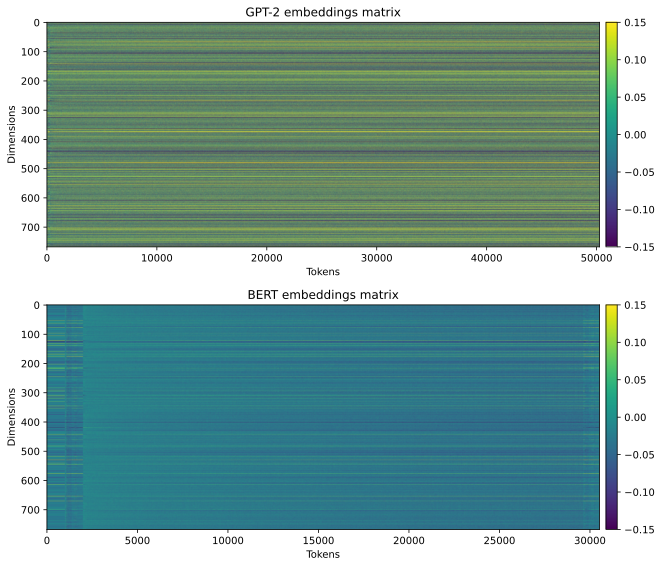

In [12]:
fig, axs = plt.subplots(2,1,figsize=(10,8))

# GPT embeddings
h = axs[0].imshow(embeddingsG.T, aspect='auto', vmin=-.15, vmax=.15)
axs[0].set(xlabel="Tokens",
           ylabel="Dimensions",
           title="GPT-2 embeddings matrix")
fig.colorbar(h, ax=axs[0], pad=.01)

# BERT embeddings
h = axs[1].imshow(embeddingsB.T, aspect='auto', vmin=-.15, vmax=.15)
axs[1].set(xlabel="Tokens",
           ylabel="Dimensions",
           title="BERT embeddings matrix")
fig.colorbar(h, ax=axs[1], pad=.01)

plt.tight_layout()
plt.show()

# comparing the same token index

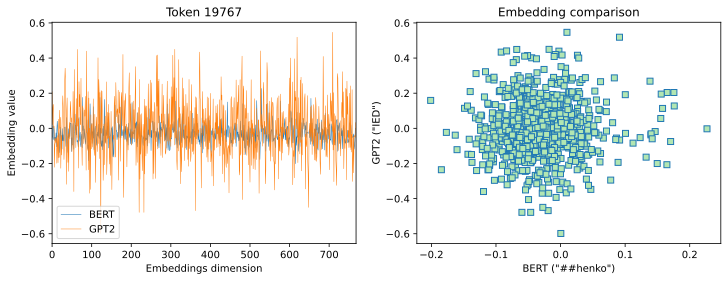

In [13]:
# pick a random token index
ridx = np.random.randint(10000, 20000)

_, axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(embeddingsB[ridx, :], label='BERT', linewidth=.5)
axs[0].plot(embeddingsG[ridx, :], label='GPT2', linewidth=.5)
axs[0].legend()
axs[0].set(xlabel="Embeddings dimension",
           ylabel="Embedding value",
           title=f"Token {ridx}",
           xlim=[0, embeddingsB.shape[1]])

axs[1].plot(embeddingsB[ridx, :], embeddingsG[ridx, :], 's', markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel=f'BERT ("{tokenizerB.decode(ridx)}")',
           ylabel=f'GPT2 ("{tokenizerG.decode(ridx)}")',
           title="Embedding comparison")

plt.show()

In [14]:
# how about the same word?
token = 'the'
token_idxB = tokenizerB.encode(token)[1]
token_idxG = tokenizerG.encode(token)[0]

print(f'BERT: "{token}" is index {token_idxB}')
print(f'GPT2: "{token}" is index {token_idxG}')

BERT: "the" is index 1996
GPT2: "the" is index 1169


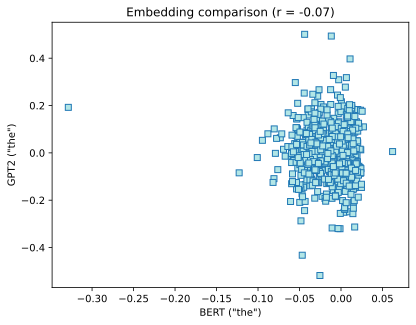

In [15]:
# their correlation
corr = np.corrcoef(embeddingsB[token_idxB, :], embeddingsG[token_idxG, :])

plt.plot(embeddingsB[token_idxB,:], embeddingsG[token_idxG,:], 's', markerfacecolor=[.7,.9,.9])
plt.gca().set(xlabel=f'BERT ("{tokenizerB.decode(token_idxB)}")',
              ylabel=f'GPT2 ("{tokenizerG.decode(token_idxG)}")',
              title=f'Embedding comparison (r = {corr[0,1]:.2f})')
plt.show()

# Distributions of embeddings characteristics

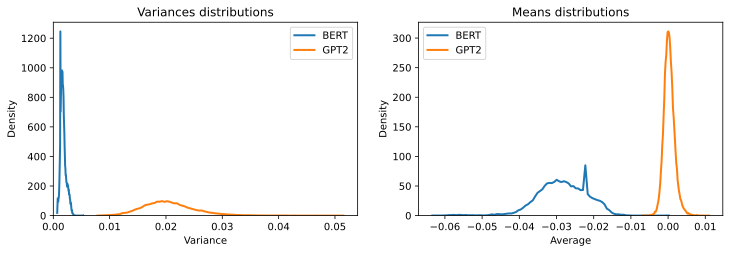

In [16]:
_, axs = plt.subplots(1,2,figsize=(12,3.5))

# compare the embeddings variances
yB, xB = np.histogram(embeddingsB.var(axis=1), bins=100, density=True)
yG, xG = np.histogram(embeddingsG.var(axis=1), bins=100, density=True)

axs[0].plot(xB[:-1], yB, linewidth=2, label='BERT')
axs[0].plot(xG[:-1], yG, linewidth=2, label='GPT2')
axs[0].set(xlabel='Variance',
           ylabel='Density',
           xlim=[0,None],
           ylim=[0,None],
           title='Variances distributions')
axs[0].legend()

# compare the embeddings means
yB, xB = np.histogram(embeddingsB.mean(axis=1), bins=100, density=True)
yG, xG = np.histogram(embeddingsG.mean(axis=1), bins=100, density=True)

axs[1].plot(xB[:-1], yB, linewidth=2, label='BERT')
axs[1].plot(xG[:-1], yG, linewidth=2, label='GPT2')
axs[1].set(xlabel='Average',
           ylabel='Density',
           ylim=[0,None],
           title='Means distributions')
axs[1].legend()

plt.show()